# AutoScan AI — Backend
### Vehicle Damage Detection using a Convolutional Neural Network

This notebook is the **complete backend** for the AutoScan AI project. Running all cells will:

1. Load and inspect the vehicle damage dataset (`training/` + `validation/`, each with `damage/` and `undamage/` subfolders)
2. Define and train a custom CNN classifier from scratch
3. Evaluate the model (loss/accuracy curves, confusion matrix, precision/recall/F1)
4. Save the trained model weights to `../models/car_damage_cnn.pt`
5. Start a **Flask API server** on `http://localhost:5050` that the frontend (`index.html` / `analysis.html`) talks to directly

> **Run this notebook top to bottom ("Run All") and leave it running** — the last cell starts a live web server that stays up as long as the kernel is alive. Then open `analysis.html` in a browser (served via `python -m http.server`, not double-clicked) to use the tool.


## 1. Imports & Configuration

In [1]:

import os
import io
import json
import base64
import threading
import time
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

print("Torch version:", torch.__version__)


Torch version: 2.13.0


In [2]:

# ── Configuration ──
DATA_DIR       = "../data/raw"
TRAIN_DIR      = os.path.join(DATA_DIR, "training")
VAL_DIR        = os.path.join(DATA_DIR, "validation")

MODEL_DIR      = "../models"
MODEL_PATH     = os.path.join(MODEL_DIR, "car_damage_cnn.pt")
os.makedirs(MODEL_DIR, exist_ok=True)

IMAGE_SIZE     = 128          # images are resized to IMAGE_SIZE x IMAGE_SIZE
BATCH_SIZE     = 32
EPOCHS         = 15
LEARNING_RATE  = 1e-3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cpu


## 2. Dataset

The dataset is expected in this exact layout (already provided by the student, no manual split needed):

```
data/raw/
├── training/
│   ├── damage/
│   └── undamage/
└── validation/
    ├── damage/
    └── undamage/
```

`torchvision.datasets.ImageFolder` maps each subfolder to a class automatically. We resize every image to `IMAGE_SIZE x IMAGE_SIZE`, normalize pixel values, and apply light data augmentation (random flip/rotation) on the training set only — this helps the model generalize better on a moderately-sized dataset.


In [3]:

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=val_transform)

# ImageFolder assigns indices alphabetically: 'damage' -> 0, 'undamage' -> 1
print("Class mapping:", train_dataset.class_to_idx)
CLASS_TO_IDX = train_dataset.class_to_idx
DAMAGE_IDX   = CLASS_TO_IDX["damage"]

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Training images:   {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")


Class mapping: {'damage': 0, 'undamage': 1}
Training images:   1840
Validation images: 460


Training set:   {'damage': 920, 'undamage': 920}
Validation set: {'damage': 230, 'undamage': 230}


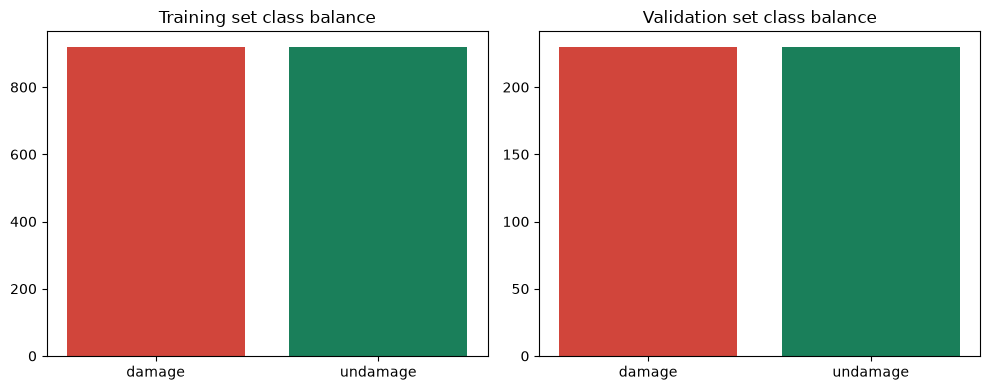

In [4]:
# ── Sanity check: class balance ──
from collections import Counter

os.makedirs("../report", exist_ok=True)   # ← added: ensure output dir exists

train_counts = Counter([train_dataset.classes[label] for _, label in train_dataset.samples])
val_counts   = Counter([val_dataset.classes[label]   for _, label in val_dataset.samples])

print("Training set:  ", dict(train_counts))
print("Validation set:", dict(val_counts))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(train_counts.keys(), train_counts.values(), color=["#d1453b", "#1a7f5a"])
axes[0].set_title("Training set class balance")
axes[1].bar(val_counts.keys(), val_counts.values(), color=["#d1453b", "#1a7f5a"])
axes[1].set_title("Validation set class balance")
plt.tight_layout()
plt.savefig("../report/class_balance.png", dpi=120)
plt.show()

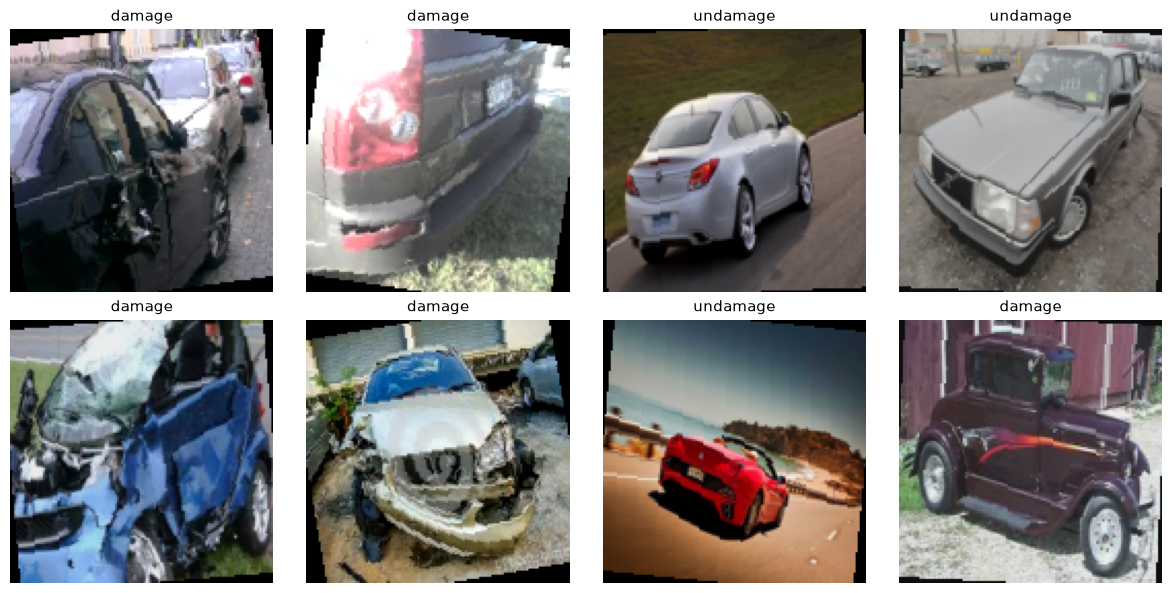

In [5]:

# ── Sanity check: visualize a batch of training images ──
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i >= len(images):
        break
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    label_name = train_dataset.classes[labels[i]]
    ax.imshow(img)
    ax.set_title(label_name, fontsize=11)
    ax.axis("off")
plt.tight_layout()
plt.savefig("../report/sample_batch.png", dpi=120)
plt.show()


## 3. Model — Custom CNN Architecture

A small convolutional network built from scratch (no pretrained backbone), designed to train quickly on CPU/GPU while still being deep enough to learn meaningful damage-related features:

- 4 convolutional blocks (`Conv → BatchNorm → ReLU → MaxPool`), channel depth doubling each block: 32 → 64 → 128 → 256
- Global average pooling to keep the parameter count low and reduce overfitting
- A fully-connected classifier head with dropout
- Single sigmoid output: probability that the image is **damaged**


In [6]:

class CarDamageCNN(nn.Module):
    def __init__(self):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            conv_block(3,   32),
            conv_block(32,  64),
            conv_block(64,  128),
            conv_block(128, 256),
        )

        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, 1),   # single logit -> sigmoid for binary classification
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x

model = CarDamageCNN().to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {n_params:,}")


CarDamageCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)

## 4. Training

Binary cross-entropy loss (`BCEWithLogitsLoss`, numerically stable with raw logits) and the Adam optimizer. We track training/validation loss and accuracy every epoch — these curves go directly into the project report.


In [7]:

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.float().unsqueeze(1).to(DEVICE)  # damage-class-index used as target directly

            if train:
                optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            if train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += images.size(0)

    return total_loss / total, correct / total


print(f"{'Epoch':<7}{'Train Loss':<13}{'Train Acc':<12}{'Val Loss':<12}{'Val Acc':<10}")
print("-" * 54)

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc     = run_epoch(val_loader,   train=False)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"{epoch:<7}{train_loss:<13.4f}{train_acc:<12.4f}{val_loss:<12.4f}{val_acc:<10.4f}")


Epoch  Train Loss   Train Acc   Val Loss    Val Acc   
------------------------------------------------------
1      0.6801       0.5582      0.6642      0.5978    
2      0.6422       0.6353      0.6432      0.6217    
3      0.5987       0.6886      0.8319      0.5609    
4      0.5743       0.7038      0.5108      0.7522    
5      0.5392       0.7321      0.7203      0.6435    
6      0.5122       0.7587      0.5055      0.7522    
7      0.5108       0.7592      0.6813      0.6391    
8      0.4845       0.7799      0.6755      0.7065    
9      0.4720       0.7761      0.4590      0.7913    
10     0.4902       0.7717      0.5324      0.7478    
11     0.4369       0.8060      0.4072      0.8130    
12     0.4541       0.7902      0.4937      0.7804    
13     0.4149       0.8120      0.5067      0.7739    
14     0.4361       0.8000      0.3613      0.8457    
15     0.4058       0.8266      0.3643      0.8435    


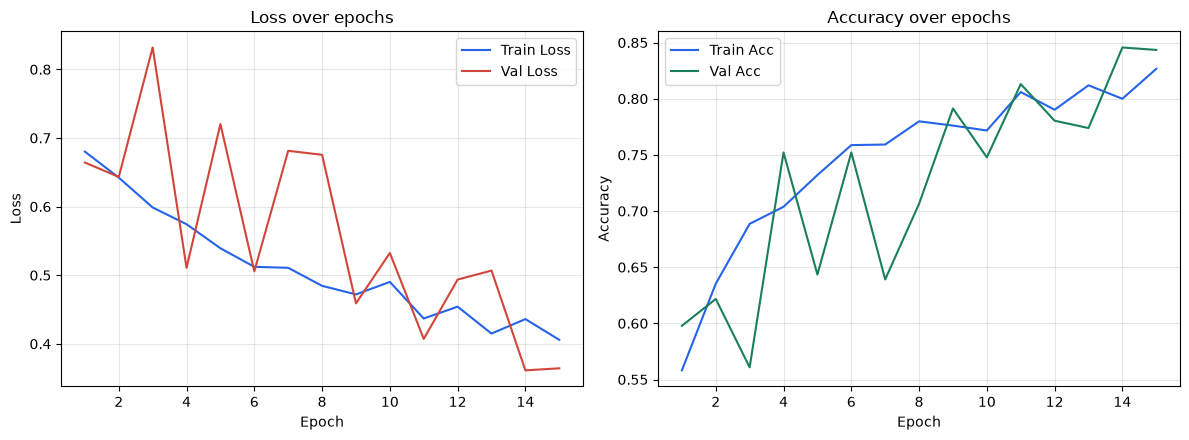

In [8]:

# ── Plot training curves (report figure) ──
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", color="#2563eb")
axes[0].plot(epochs_range, history["val_loss"],   label="Val Loss",   color="#d1453b")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss over epochs")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], label="Train Acc", color="#2563eb")
axes[1].plot(epochs_range, history["val_acc"],   label="Val Acc",   color="#1a7f5a")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Accuracy over epochs")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../report/training_curves.png", dpi=120)
plt.show()


## 5. Evaluation

Confusion matrix and precision/recall/F1 on the held-out validation set — the key metrics table for the report's "Results" section.


Confusion Matrix:
[[217  13]
 [ 59 171]]

Classification Report:
              precision    recall  f1-score   support

      damage       0.79      0.94      0.86       230
    undamage       0.93      0.74      0.83       230

    accuracy                           0.84       460
   macro avg       0.86      0.84      0.84       460
weighted avg       0.86      0.84      0.84       460



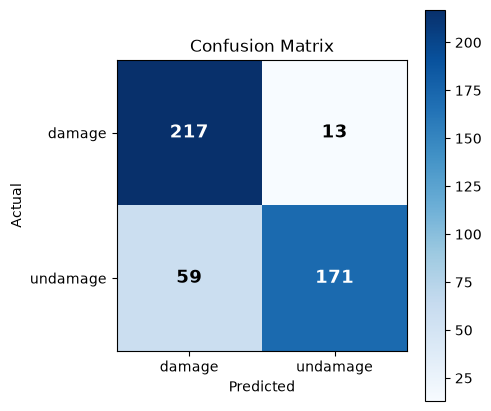

In [9]:

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds = (torch.sigmoid(outputs) > 0.5).float().cpu().numpy().flatten()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.numpy().tolist())

class_names = [val_dataset.classes[0], val_dataset.classes[1]]

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)
print()
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(class_names)
ax.set_yticks([0, 1]); ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title("Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=13, fontweight="bold")
plt.colorbar(im)
plt.tight_layout()
plt.savefig("../report/confusion_matrix.png", dpi=120)
plt.show()


## 6. Save the trained model

In [10]:

torch.save({
    "model_state_dict": model.state_dict(),
    "class_to_idx": CLASS_TO_IDX,
    "image_size": IMAGE_SIZE,
}, MODEL_PATH)

print(f"Model saved to {MODEL_PATH}")


Model saved to ../models/car_damage_cnn.pt


## 7. Inference function

This is the exact function the Flask API calls for every prediction request — takes raw image bytes (from either the upload form or a captured camera frame) and returns a damaged/undamaged verdict with a confidence score.


In [11]:

inference_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

DAMAGE_LABEL   = "damage"
UNDAMAGE_LABEL = "undamage"


def predict_image(image_bytes):
    '''Takes raw image bytes -> returns dict with damaged (bool), confidence (float), label (str).'''
    image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    tensor = inference_transform(image).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        logit = model(tensor)
        prob_damage = torch.sigmoid(logit).item()   # probability of class index DAMAGE_IDX

    # if 'damage' is class 0, a HIGH sigmoid output means class 1 (undamage) is more likely,
    # so we need to correctly orient the probability relative to the 'damage' class.
    if DAMAGE_IDX == 1:
        p_damaged = prob_damage
    else:
        p_damaged = 1 - prob_damage

    is_damaged = p_damaged > 0.5
    confidence = p_damaged if is_damaged else (1 - p_damaged)

    return {
        "damaged": bool(is_damaged),
        "confidence": round(float(confidence), 4),
        "label": "Dent or scratch detected" if is_damaged else "No visible damage detected",
    }


In [12]:

# ── Quick manual test on one validation image ──
sample_path, sample_label_idx = val_dataset.samples[0]
with open(sample_path, "rb") as f:
    sample_bytes = f.read()

result = predict_image(sample_bytes)
print("Test image:", sample_path)
print("True label:", val_dataset.classes[sample_label_idx])
print("Prediction:", result)


Test image: ../data/raw/validation/damage/0001.JPEG
True label: damage
Prediction: {'damaged': True, 'confidence': 0.9224, 'label': 'Dent or scratch detected'}


## 8. Flask API Server

This cell **is the backend**. It starts a Flask server on a background thread so the notebook kernel stays interactive, exposing three endpoints for the frontend:

| Method | Route      | Purpose                                              |
|--------|------------|-------------------------------------------------------|
| GET    | `/health`  | Quick check that the server + model are up            |
| POST   | `/predict` | Accepts an image, returns `{damaged, confidence, label}` |
| POST   | `/report`  | Accepts a scan result, returns a downloadable PDF report |

Run this cell and **leave the notebook open** — as long as the kernel is alive, `http://localhost:5050` is live. Then serve the frontend separately (`python -m http.server 8000` inside the project folder) and open `analysis.html` in your browser.


In [13]:

from flask import Flask, request, jsonify, send_file
from flask_cors import CORS
from reportlab.lib.pagesizes import A4
from reportlab.lib.units import mm
from reportlab.pdfgen import canvas as pdf_canvas
from reportlab.lib.utils import ImageReader

app = Flask(__name__)
CORS(app)  # allow requests from the frontend running on a different local port


@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "ok", "model_loaded": True, "device": str(DEVICE)})


@app.route("/predict", methods=["POST"])
def predict():
    if "image" not in request.files:
        return jsonify({"error": "No image file provided"}), 400

    file = request.files["image"]
    image_bytes = file.read()

    try:
        result = predict_image(image_bytes)
        return jsonify(result)
    except Exception as e:
        return jsonify({"error": str(e)}), 500


@app.route("/report", methods=["POST"])
def report():
    '''Generates a one-page PDF report for a single scan result.'''
    data = request.get_json(force=True)

    damaged    = data.get("damaged", False)
    confidence = data.get("confidence", 0.0)
    label      = data.get("label", "")
    image_b64  = data.get("image", "")
    timestamp  = data.get("timestamp", datetime.now().isoformat())

    buffer = io.BytesIO()
    c = pdf_canvas.Canvas(buffer, pagesize=A4)
    width, height = A4

    # Header
    c.setFillColorRGB(0.08, 0.09, 0.12)
    c.rect(0, height - 30 * mm, width, 30 * mm, fill=1, stroke=0)
    c.setFillColorRGB(1, 1, 1)
    c.setFont("Helvetica-Bold", 20)
    c.drawString(20 * mm, height - 18 * mm, "AutoScan AI — Inspection Report")
    c.setFont("Helvetica", 10)
    c.drawString(20 * mm, height - 25 * mm, f"Generated: {timestamp}")

    y = height - 45 * mm

    # Embed the scanned image, if provided as a base64 data URL
    if image_b64.startswith("data:image"):
        try:
            header, encoded = image_b64.split(",", 1)
            img_bytes = base64.b64decode(encoded)
            img = ImageReader(io.BytesIO(img_bytes))
            img_w, img_h = 80 * mm, 55 * mm
            c.rect(20 * mm, y - img_h, img_w, img_h, stroke=1, fill=0)
            c.drawImage(img, 20 * mm, y - img_h, width=img_w, height=img_h,
                         preserveAspectRatio=True, anchor='c')
        except Exception:
            pass

    # Result block
    text_x = 110 * mm
    verdict = "DAMAGED" if damaged else "NORMAL"
    verdict_color = (0.82, 0.27, 0.23) if damaged else (0.10, 0.50, 0.35)

    c.setFillColorRGB(*verdict_color)
    c.setFont("Helvetica-Bold", 22)
    c.drawString(text_x, y - 10 * mm, verdict)

    c.setFillColorRGB(0.1, 0.1, 0.1)
    c.setFont("Helvetica", 12)
    c.drawString(text_x, y - 22 * mm, f"Confidence: {round(confidence * 100, 1)}%")
    c.setFont("Helvetica", 10)
    c.drawString(text_x, y - 30 * mm, label)

    # Footer note
    c.setFont("Helvetica-Oblique", 9)
    c.setFillColorRGB(0.4, 0.4, 0.4)
    c.drawString(20 * mm, 20 * mm,
                  "Generated by AutoScan AI \u2014 CNN-based vehicle damage classifier. University project.")

    c.showPage()
    c.save()
    buffer.seek(0)

    return send_file(
        buffer,
        mimetype="application/pdf",
        as_attachment=True,
        download_name="autoscan-report.pdf",
    )


def run_server():
    app.run(host="0.0.0.0", port=5050, debug=False, use_reloader=False)


server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()

time.sleep(1)
print("✅ Flask server running at http://localhost:5050")
print("   Endpoints: GET /health · POST /predict · POST /report")
print("   Leave this notebook running, then open analysis.html in your browser.")


 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5050
 * Running on http://172.21.226.107:5050
Press CTRL+C to quit
127.0.0.1 - - [16/Jul/2026 10:53:56] "GET /health HTTP/1.1" 200 -


✅ Flask server running at http://localhost:5050
   Endpoints: GET /health · POST /predict · POST /report
   Leave this notebook running, then open analysis.html in your browser.
